# Exploratory Data Analysis

It is the main nootebook related to Exploratory Data Analysis (EDA) of https://www.kaggle.com/datasets/sahistapatel96/bankadditionalfullcsv dataset.

All intermediate conclusions are provided at the end of each section and marked with <span style="background-color: #4FC3F7">light-blue background</span>

Final thoughts and conclusions are provided in the last section at the end of the notebook.

## Notebook initialization

In [1]:
# Notebook initialization
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd()

while not (ROOT / "src").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

# print("Project root:", ROOT)

## Imports & Load data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_raw_data

raw_df = load_raw_data()
raw_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Missing values

In [3]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [4]:
raw_df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

<span style="background-color: #4FC3F7">
 - no missing values in dataset
</span>

## Target Column

In [5]:
target_col = "y"
raw_df[target_col].value_counts(normalize=True)

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

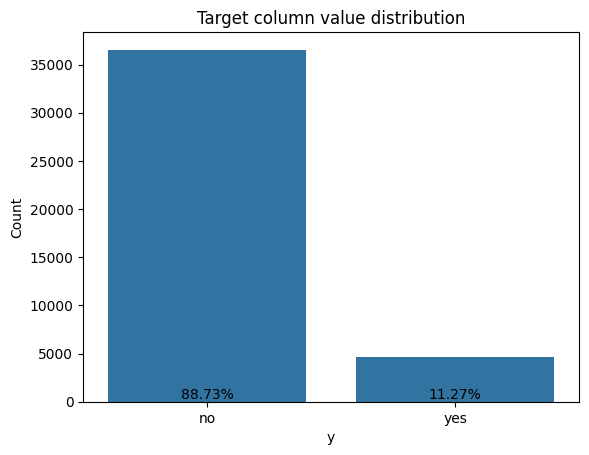

In [6]:
from src.visualizations import plot_column_distribution

plot_column_distribution(raw_df, target_col, title="Target column value distribution")

<span style="background-color: #4FC3F7">
 - there is target values class imbalance in training data
</span>

## Split numeric and categorical columns

In [7]:
from src.data import split_numeric_categorical

splits = split_numeric_categorical(raw_df)

X_num = splits["X_numeric"]
y_num = splits["y_numeric"]
numeric_df = pd.concat([X_num, y_num], axis=1)

X_cat = splits["X_categorical"]
y_cat = splits["y_categorical"]
categorical_df = pd.concat([X_cat, y_cat], axis=1)

X_num.shape, X_cat.shape, y_num.shape, y_cat.shape

((41188, 10), (41188, 10), (41188,), (41188,))

<span style="background-color: #4FC3F7">
 - there are 10 numeric and 10 categorical features in dataset
</span>

## Correlations numeric

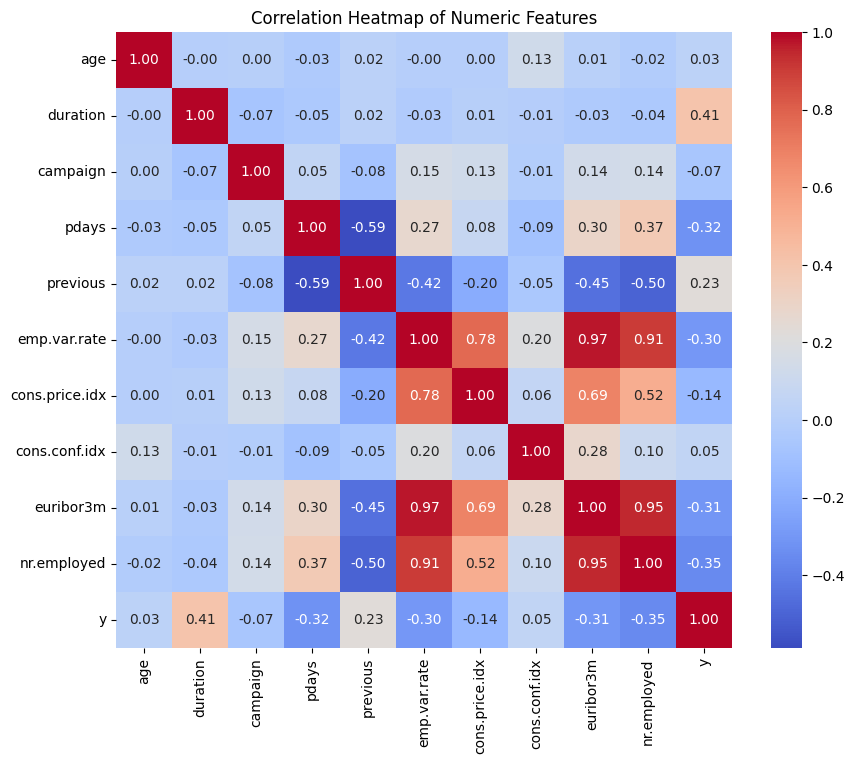

In [8]:
from src.visualizations import plot_correlation_heatmap

plot_correlation_heatmap(numeric_df)

## Numeric columns

### All box-plots (raw data)

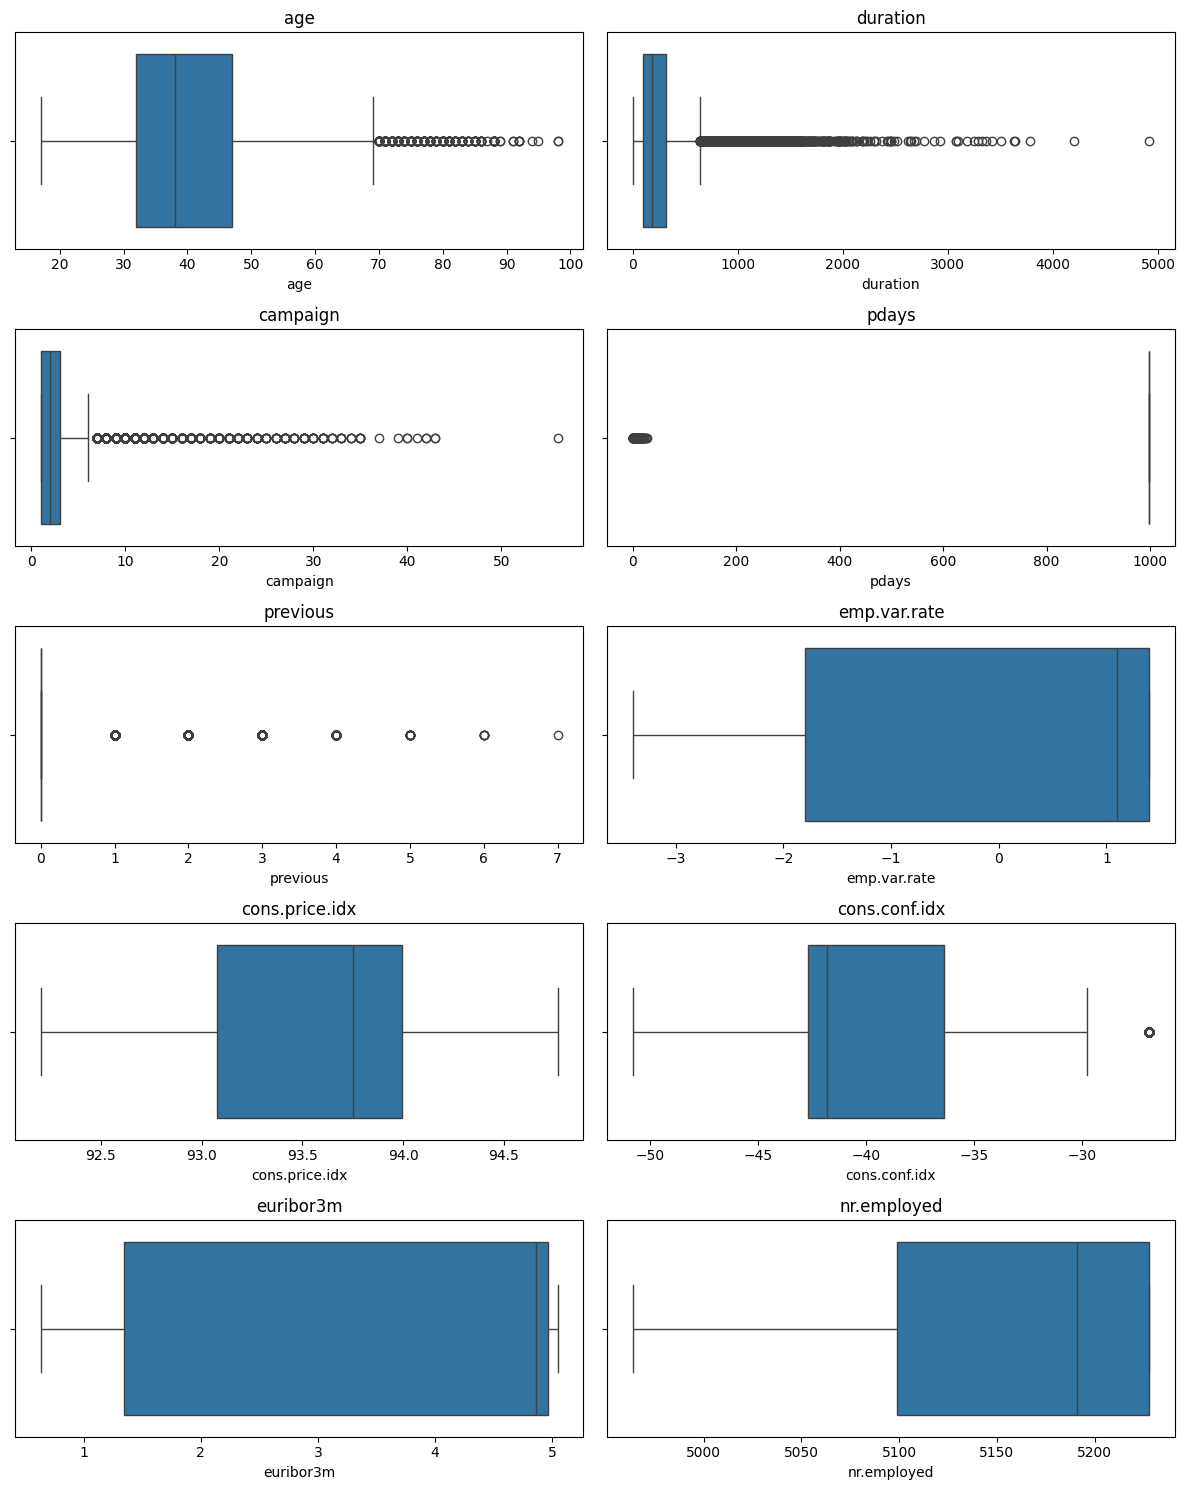

In [9]:
from src.visualizations import plot_numeric_boxplots_grid

plot_numeric_boxplots_grid(numeric_df, target_col)

<span style="background-color: #4FC3F7">
 - duration, campaigns, pdays, previous columns require additional analysis
</span>

### Duration column vs. target

In [10]:
numeric_df["duration"].describe()

count    41188.000000
mean       258.285010
std        259.279249
min          0.000000
25%        102.000000
50%        180.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64

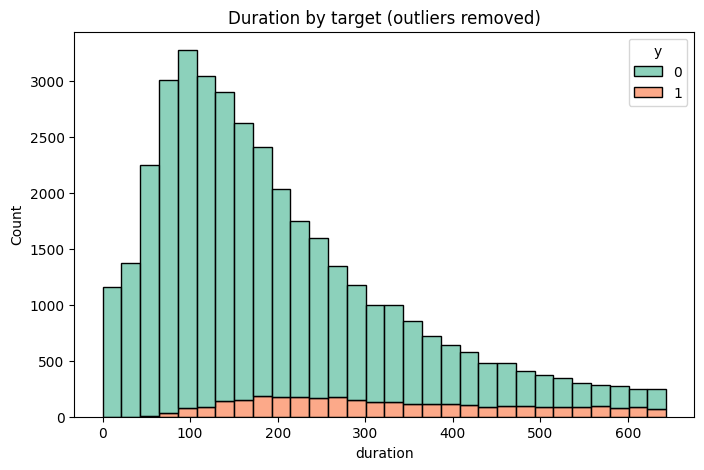

In [11]:
from src.visualizations import plot_histogram
from src.outliers import remove_outliers_iqr, replace_outliers_iqr

plot_histogram(
    remove_outliers_iqr(numeric_df, "duration"),
    "duration",
    target_col="y",
    show_pct=False,
    title="Duration by target (outliers removed)",
)

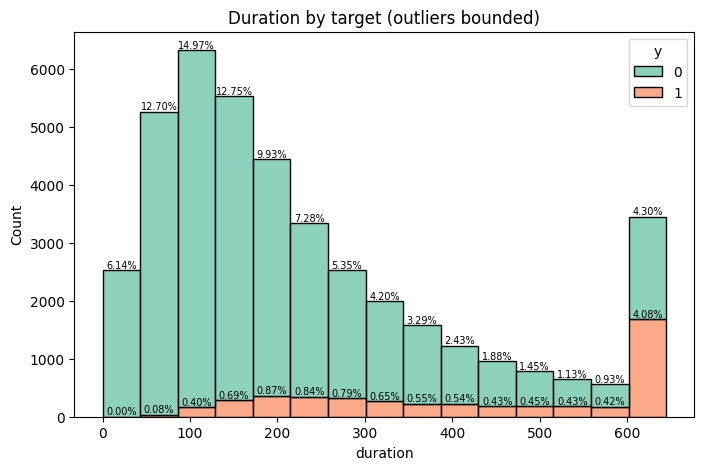

In [12]:
plot_histogram(
    replace_outliers_iqr(numeric_df, "duration", replace_with=None), 
    "duration",
    target_col="y",
    show_pct=True,
    bins=15,
    title="Duration by target (outliers bounded)",
)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**Conclusion – Feature `duration`**

- When `duration = 0`, the outcome is always **`no`**  
- The probability of **`yes` increases as call duration increases**  
- However, `duration` represents the **length of the last contact with the client**, which is only known **after the call has finished**  
- Therefore, using this variable in modeling would introduce **data leakage**

**Decision:**  
`duration` will **not be included in the final predictive model** and will be used **only for exploratory analysis**

</span>

### Campaign column vs. target

In [13]:
numeric_df["campaign"].describe()

count    41188.000000
mean         2.567593
std          2.770014
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         56.000000
Name: campaign, dtype: float64

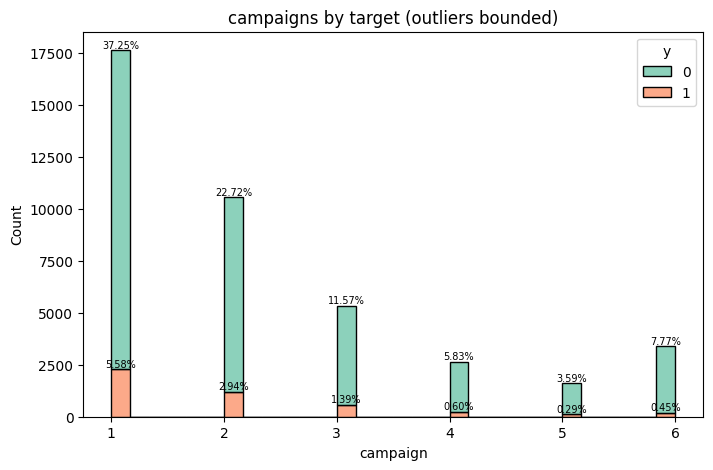

In [14]:
plot_histogram(
    replace_outliers_iqr(numeric_df, "campaign", replace_with=None),
    "campaign",
    target_col="y",
    show_pct=True,
    title="campaigns by target (outliers bounded)",
)

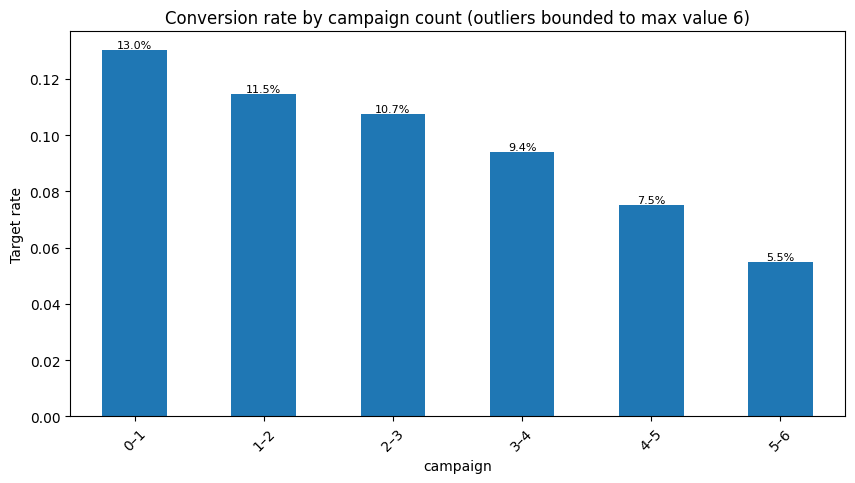

In [15]:
from src.visualizations import plot_target_rate_by_bin

plot_target_rate_by_bin(
    replace_outliers_iqr(numeric_df, "campaign", replace_with=None),
    col="campaign",
    target_col="y",
    title="Conversion rate by campaign count (outliers bounded to max value 6)",
)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**Conclusion – Feature `campaign`**

- The probability of the **`yes` target decreases as the number of contacts in the current campaign increases**
- The dataset contains values up to **56 contacts**, but the vast majority of observations are **≤ 6**
- Values above **6 appear to be extreme outliers and occur very rarely**

**Modeling considerations**

- The `campaign` feature represents the **number of contacts performed during the current campaign, including the last contact**
- Since the model should represent the situation **before the current call**, it is more consistent to use the **number of previous contacts only**

**Decision**

- Create a transformed feature representing **previous campaign contacts**:  
  `campaign_prev = campaign - 1`
- Cap the value at **6** to reduce the influence of extreme outliers  
- Use the transformed feature (`campaign_prev`) in the final model

</span>

### previous column vs. target

In [16]:
numeric_df[numeric_df["previous"] != 0].shape, numeric_df[numeric_df["previous"] == 0].shape

((5625, 11), (35563, 11))

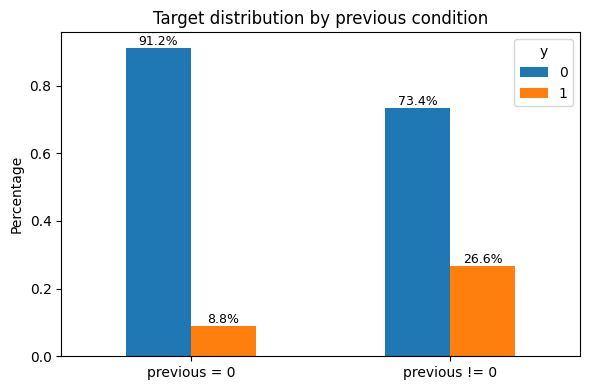

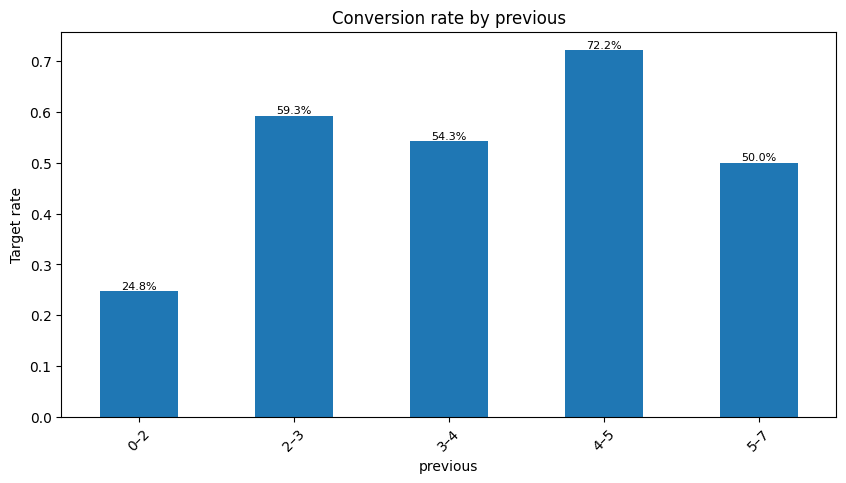

In [17]:
from src.visualizations import plot_target_distribution_by_value

plot_target_distribution_by_value(numeric_df, "previous", 0, target_col)

plot_target_rate_by_bin(
    numeric_df[numeric_df["previous"] > 0],
    col="previous",
    target_col="y",
    title="Conversion rate by previous",
    bins=5
)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**Conclusion – Feature `previous`**

- Clients with **`previous > 0`** (i.e., contacted in previous campaigns) show a **higher probability of the target value `yes`**
- Only **5,625 rows (~14% of the dataset)** have `previous > 0`, meaning most clients were **not contacted before the current campaign**
- Despite the relatively small proportion, the observed relationship with the target suggests that **previous contact history may carry useful predictive information**

**Decision**

- Keep the `previous` feature in the model **without transformation**
- The feature may help capture **prior customer engagement with marketing campaigns**

</span>

### pdays column vs. target

In [18]:
numeric_df["pdays"].describe()

count    41188.000000
mean       962.475454
std        186.910907
min          0.000000
25%        999.000000
50%        999.000000
75%        999.000000
max        999.000000
Name: pdays, dtype: float64

In [19]:
numeric_df[numeric_df["pdays"] != 999].shape, numeric_df[numeric_df["pdays"] == 999].shape

((1515, 11), (39673, 11))

In [20]:
(
    numeric_df[(numeric_df["pdays"] == 999) & (numeric_df["previous"] != 0)].shape[0], # no pdays but previous exist
    numeric_df[(numeric_df["pdays"] == 999) & (numeric_df["previous"] == 0)].shape[0], # no pdays and no previous
    numeric_df[(numeric_df["pdays"] != 999) & (numeric_df["previous"] != 0)].shape[0], # both pdays and previous exist
    numeric_df[(numeric_df["pdays"] != 999) & (numeric_df["previous"] == 0)].shape[0], # no previous but pdays exist
)

(4110, 35563, 1515, 0)

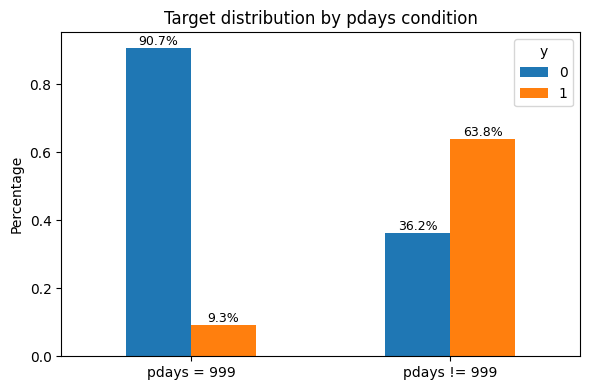

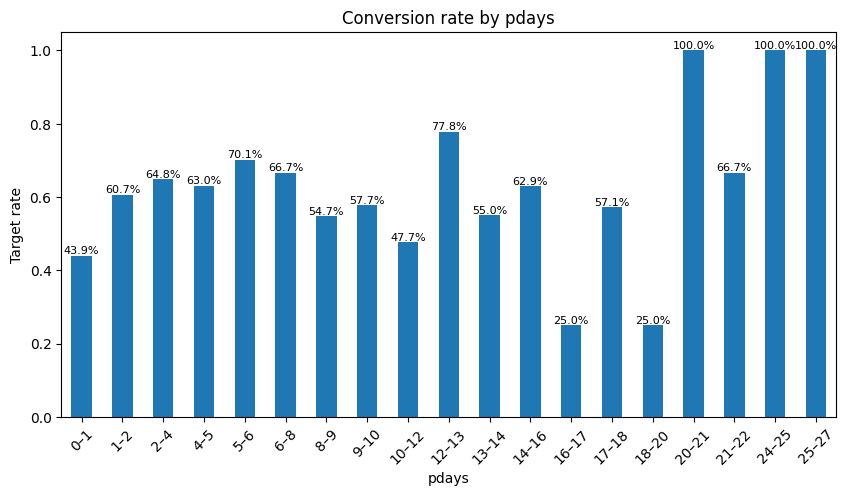

In [21]:
plot_target_distribution_by_value(numeric_df, "pdays", 999, target_col)

plot_target_rate_by_bin(
    numeric_df[numeric_df["pdays"] < 999],
    col="pdays",
    target_col="y",
    title="Conversion rate by pdays",
)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**Conclusion – Feature `pdays`**

- Clients who were **previously contacted in a past campaign (`pdays != 999`)** show a **higher probability of the target value `yes`**
- Only **1,515 rows (~4% of the dataset)** have `pdays != 999`, meaning that the vast majority of clients **were not contacted in previous campaigns**
- The **exact number of days since the previous contact does not show a clear or consistent relationship with the target**
- All rows with **`pdays != 999` also have `previous > 0`**, but not all rows with **`previous > 0` have a valid `pdays` value**, suggesting that the two features capture **related but not identical information**

**Modeling considerations**

- The value **`999` represents "client was not previously contacted"**, which makes the variable **highly skewed**
- Therefore, treating `pdays` as a continuous numeric feature may not be optimal

**Decision**

- Transform `pdays` into a categorical or binary feature, for example:
  - `pdays_contacted = 1` if `pdays != 999`, otherwise `0`
  - or grouped categories such as:
    - `not_contacted_before`
    - `contacted_recently` (e.g., `< 14 days`)
    - `contacted_long_ago` (e.g., `≥ 14 days`)

This transformation may help the model better capture the **impact of prior contact history**.

</span>

### age column vs. target

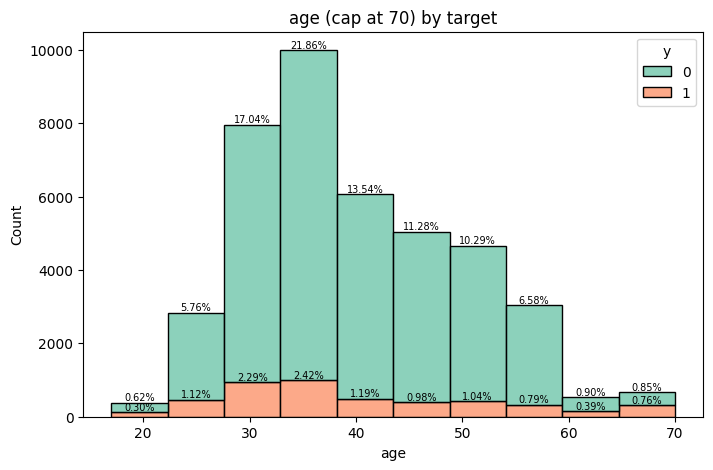

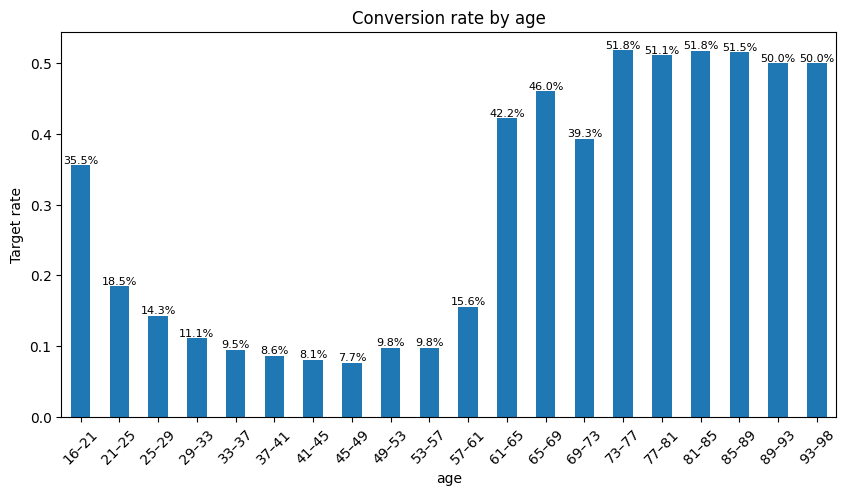

In [54]:
plot_histogram(
    replace_outliers_iqr(numeric_df, "age", replace_with=70),
    "age",
    target_col="y",
    show_pct=True,
    bins=10,
    title="age (cap at 70) by target",
)

plot_target_rate_by_bin(
    numeric_df,
    col="age",
    target_col="y",
    title="Conversion rate by age",
)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**Conclusion – Feature `age`**

- The **vast majority of clients are younger than 60**, with relatively few observations in the **60+ age group**
- Despite the smaller number of observations, clients aged **60 and above show a noticeably higher probability of the target value `yes`**
- Clients **younger than 30** also appear to have a **higher probability of `yes`** compared to the middle age group
- The **30–60 age group represents the largest portion of the dataset** but shows a relatively lower probability of `yes`

**Modeling considerations**

- The relationship between **age and the target does not appear strictly linear**
- Certain **age segments (younger and older clients)** appear to behave differently compared to the **middle-aged group**
- This suggests that **grouping age into categories may help capture differences in client behavior**

**Decision**

- Test two possible approaches during modeling:
  - Use `age` **as a continuous numeric feature**
  - Create **age group categories**, for example:
    - `young` : `age < 25`
    - `middle` : `25 ≤ age ≤ 60`
    - `old` : `age > 60`
- Select the representation that provides **better predictive performance** in the final model

</span>

### Socio-economic context columns (emp.var.rate, cons.price.idx, etc)

#### Histogram & KDE vs. target

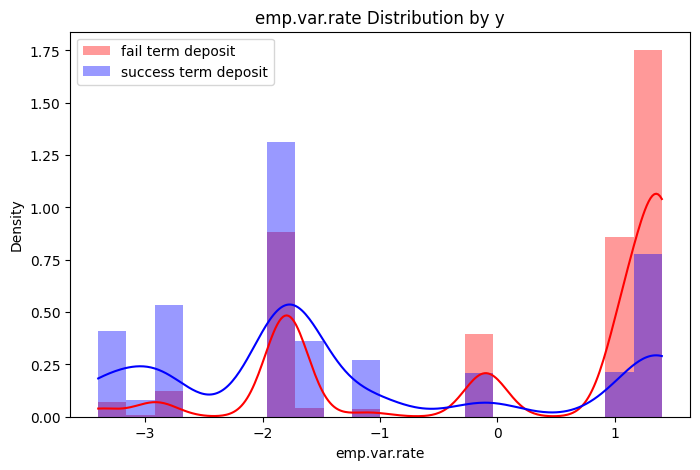

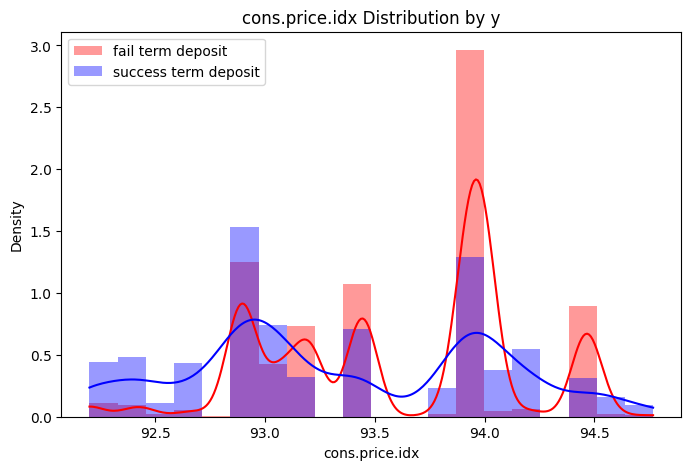

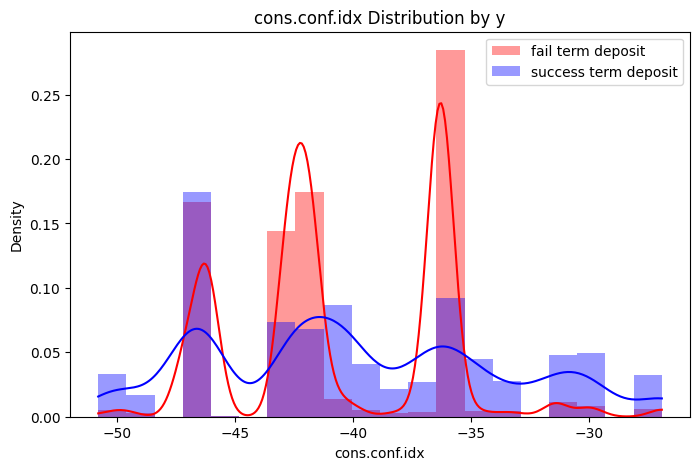

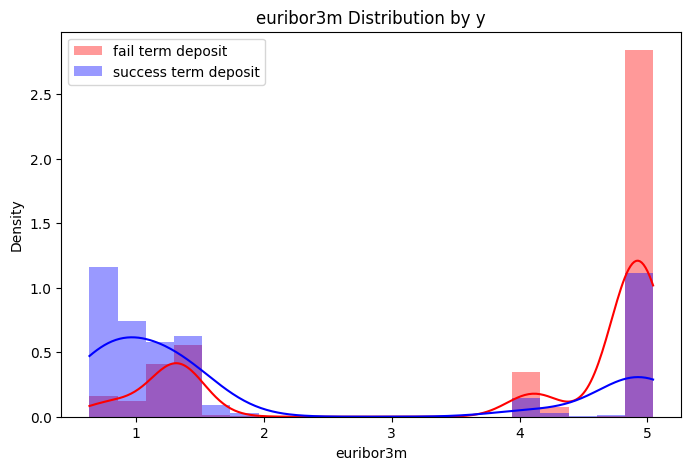

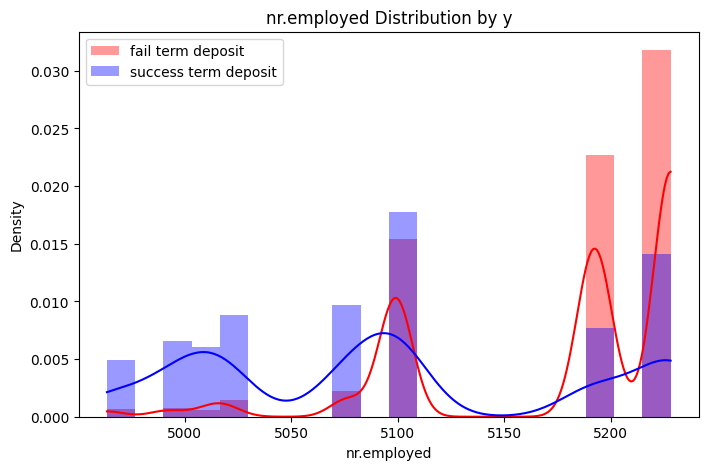

In [22]:
from src.visualizations import plt_histogram_kde

soceco_cols = ["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]

for col in soceco_cols:
    plt_histogram_kde(
        numeric_df,
        col=col,
        color_col=target_col,
        labels={0: "fail term deposit", 1: "success term deposit"},
        density=True,
        bins=20,
    )

#### Correlations

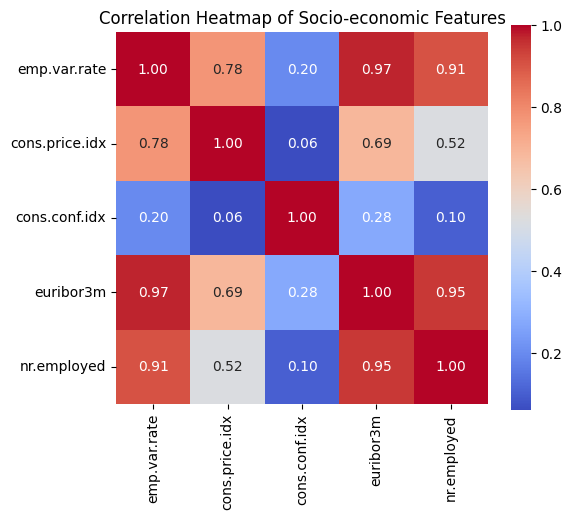

In [23]:
plot_correlation_heatmap(
    numeric_df[soceco_cols],
    figsize=(6,5),
    title="Correlation Heatmap of Socio-economic Features"
)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**Conclusion – Socio-economic Context Features**

- Higher values of **`emp.var.rate`**, **`euribor3m`**, and **`nr.employed`** are associated with a **lower probability of the target value `yes`**
- This suggests that **worse macro-economic conditions (lower rates / lower employment)** may increase the likelihood of clients subscribing to the product
- Because the relationship appears mostly **monotonic**, these variables could potentially be **binned into broader categories** (e.g., `low` / `high`) without losing much information

- The variables **`cons.price.idx`** and **`cons.conf.idx`** do not show a simple monotonic relationship with the target, but some value ranges appear to influence the probability of `yes` or `no`

**Correlation considerations**

- Socio-economic features show **strong correlations with each other**, indicating they may capture **similar macro-economic signals**
- Including all of them in the model may introduce **multicollinearity and redundant information**

**Decision**

- Consider **feature selection** among socio-economic variables  
- Potential approaches include:
  - selecting the **most informative variables**
  - **binning** monotonic variables (e.g., `emp.var.rate`, `euribor3m`, `nr.employed`)
  - evaluating **feature importance during modeling** to remove redundant predictors

</span>

## Categorical columns
### columns cardinality

In [24]:
# cardinality
categorical_df.nunique()

job            12
marital         4
education       8
default         3
housing         3
loan            3
contact         2
month          10
day_of_week     5
poutcome        3
y               2
dtype: int64

### countplots (vs target)

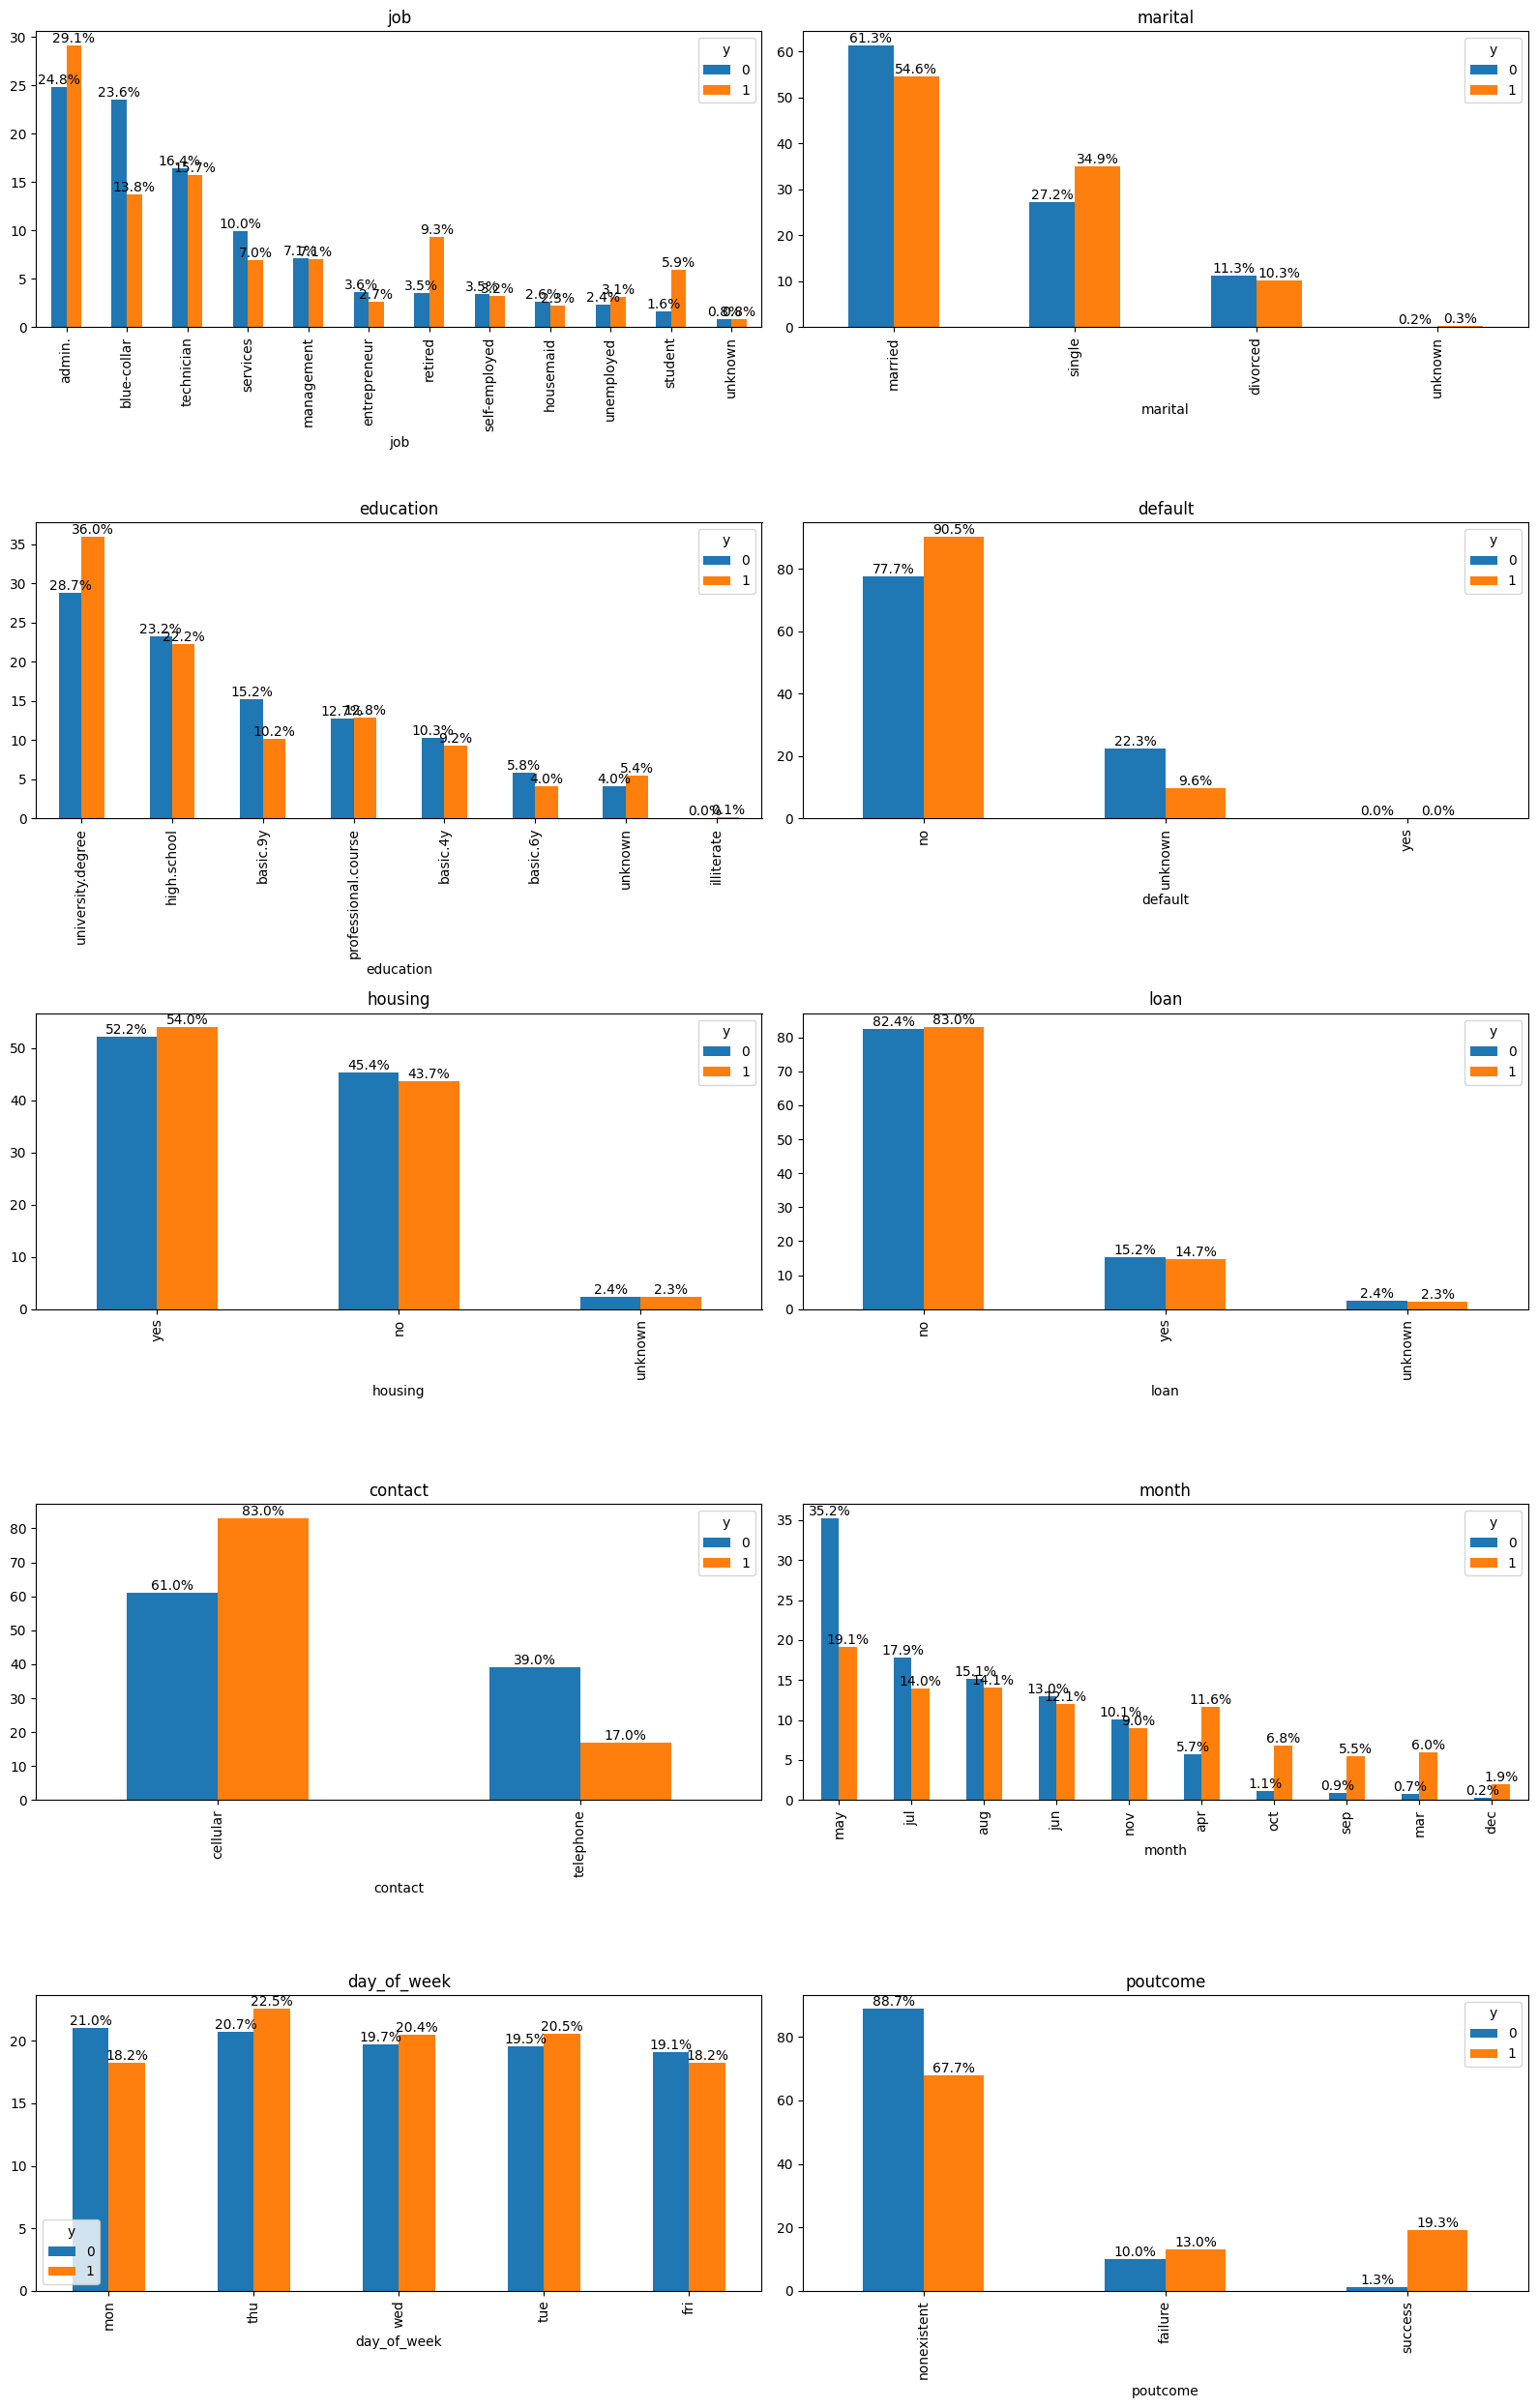

In [25]:
from src.visualizations import draw_countplot

import math

cols = [c for c in categorical_df.columns if c != target_col]

n = len(cols)
rows = math.ceil(n / 2)

fig, axes = plt.subplots(rows, 2, figsize=(16, rows * 5))
axes = axes.flatten()

for i, col in enumerate(cols):
    draw_countplot(
        categorical_df,
        col,
        hue_col=target_col,
        normalize=True,
        title=col,
        ax=axes[i],
    )

# hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

<span style="background-color: #4FC3F7; display:block; padding:10px">

**Conclusion – Initial Review of Categorical Features**

- Certain **`job` categories** (e.g., `student`, `retired`, `admin`) show a **higher probability of the target value `yes`** compared to other occupations.

- For the **`marital`** feature, clients with status **`single`** appear to have a **higher probability of `yes`** compared to `married`.

- A **higher level of `education`** seems to be associated with a **greater probability of the target value `yes`**.

- Clients with **`default = no`** show a **higher probability of subscription**, which is expected since clients with credit default may be less likely to accept financial offers.

- The **`month`** variable shows noticeable variation in conversion rates, suggesting that **seasonality or campaign timing** may influence subscription probability.

- The **`contact`** method appears to matter: **`cellular` contacts show higher probability of `yes`** compared to `telephone`.

- The **`poutcome`** feature (outcome of the previous marketing campaign) shows a **strong relationship with the target**.  
  It may be useful to analyze this feature together with **`previous`** and **`pdays`**, since they all describe **client interaction history with past campaigns**.

</span>

### Job column

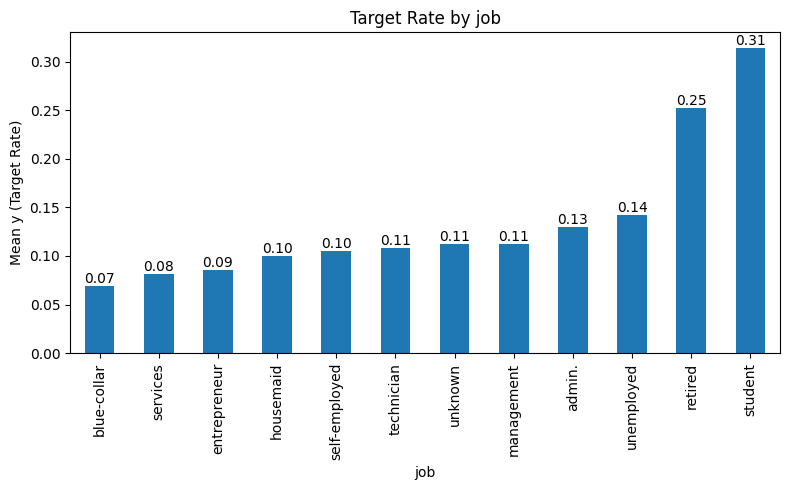

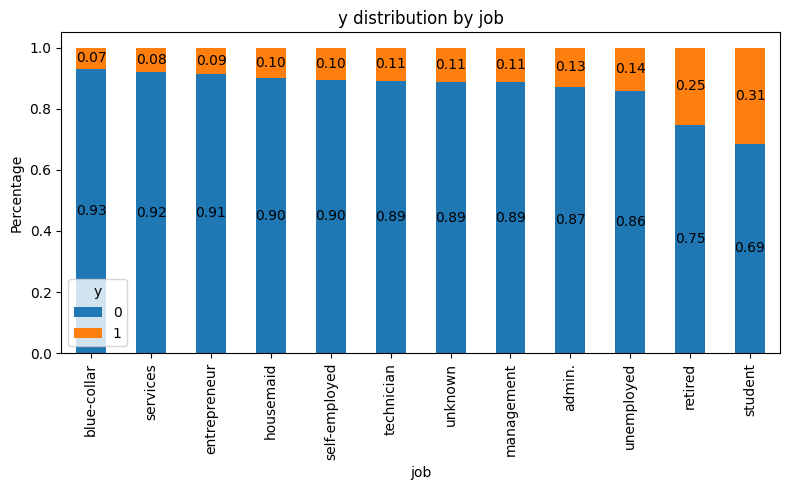

In [26]:
from src.visualizations import plot_target_rate_by_category, plot_target_distribution_by_category

plot_target_rate_by_category(
    categorical_df,
    col="job",
    target_col=target_col,
)
plot_target_distribution_by_category(
    categorical_df,
    col="job",
    target_col=target_col,
)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**Conclusion – Feature `job`**

- The **`blue-collar`** category shows the **lowest probability of the target value `yes`** among job groups.

- Clients with **`student`** and **`retired`** occupations demonstrate a **significantly higher probability of subscription** compared to most other job categories.

- Other job categories show moderate differences in conversion rate but still appear to carry **potential predictive signal**.

**Decision**

- Since `job` is a **nominal categorical feature without a natural ordering**, it is reasonable to **retain all categories**.
- The feature will be encoded using **one-hot encoding** during modeling to allow the model to capture differences between job groups.
- Consider dropping ambiguous `unknown` values to avoid multicollinearity

</span>

### Education columns

In [27]:
categorical_df["education"].value_counts()

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

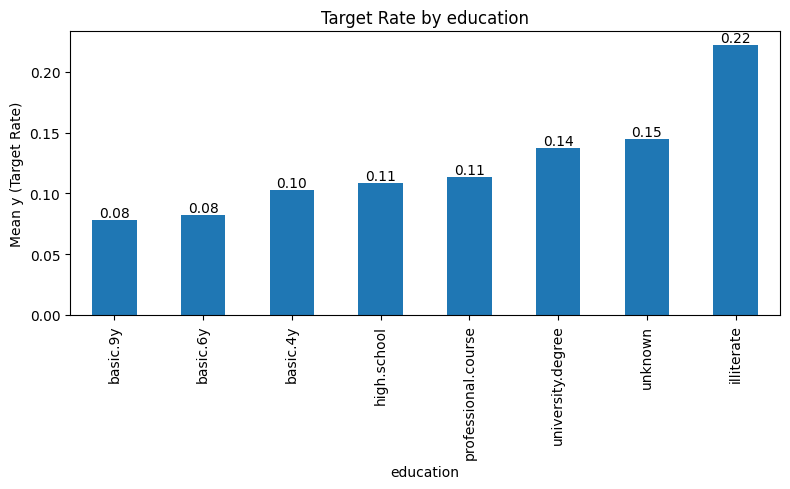

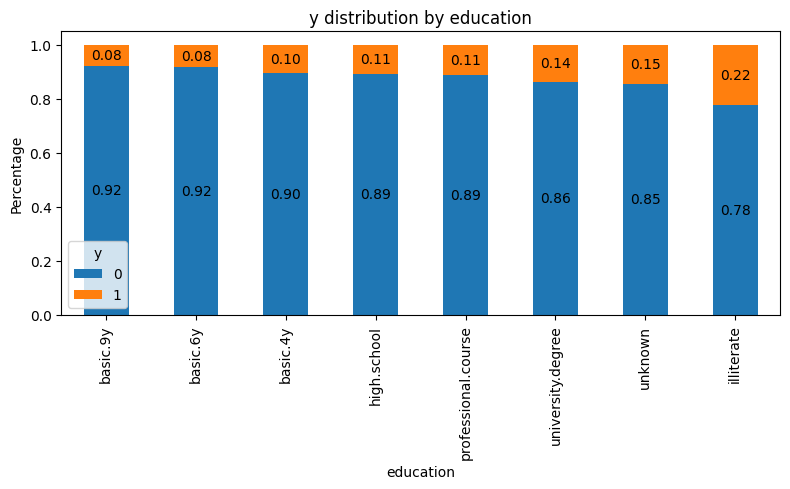

In [28]:

plot_target_rate_by_category(
    categorical_df,
    col="education",
    target_col=target_col,
)
plot_target_distribution_by_category(
    categorical_df,
    col="education",
    target_col=target_col,
)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**Conclusion – Feature `education`**

- In general, a **higher education level appears to be associated with a higher probability of the target value `yes`**.

- The categories **`illiterate`** and **`unknown`** are either very rare or ambiguous, which makes it difficult to draw reliable conclusions about their relationship with the target.

**Modeling considerations**
- `education` is a **categorical feature representing different education levels**.
- Although there is a **natural ordering of education levels**, the relationship with the target may **not be strictly linear**.
- Rare or ambiguous categories (`illiterate`, `unknown`) may introduce **noise due to the very small number of observations or ambiguity**.


**Decision**

- Keep the `education` feature in the model and **encode it using one-hot encoding**.
- Rare or ambiguous categories (`illiterate`, `unknown`) can still be preserved during encoding, but their contribution to the model may be limited.
- Consider dropping `illiterate` and `unknown` categories to avoid multicollinearity

</span>

### poutcome column vs. previous vs. target

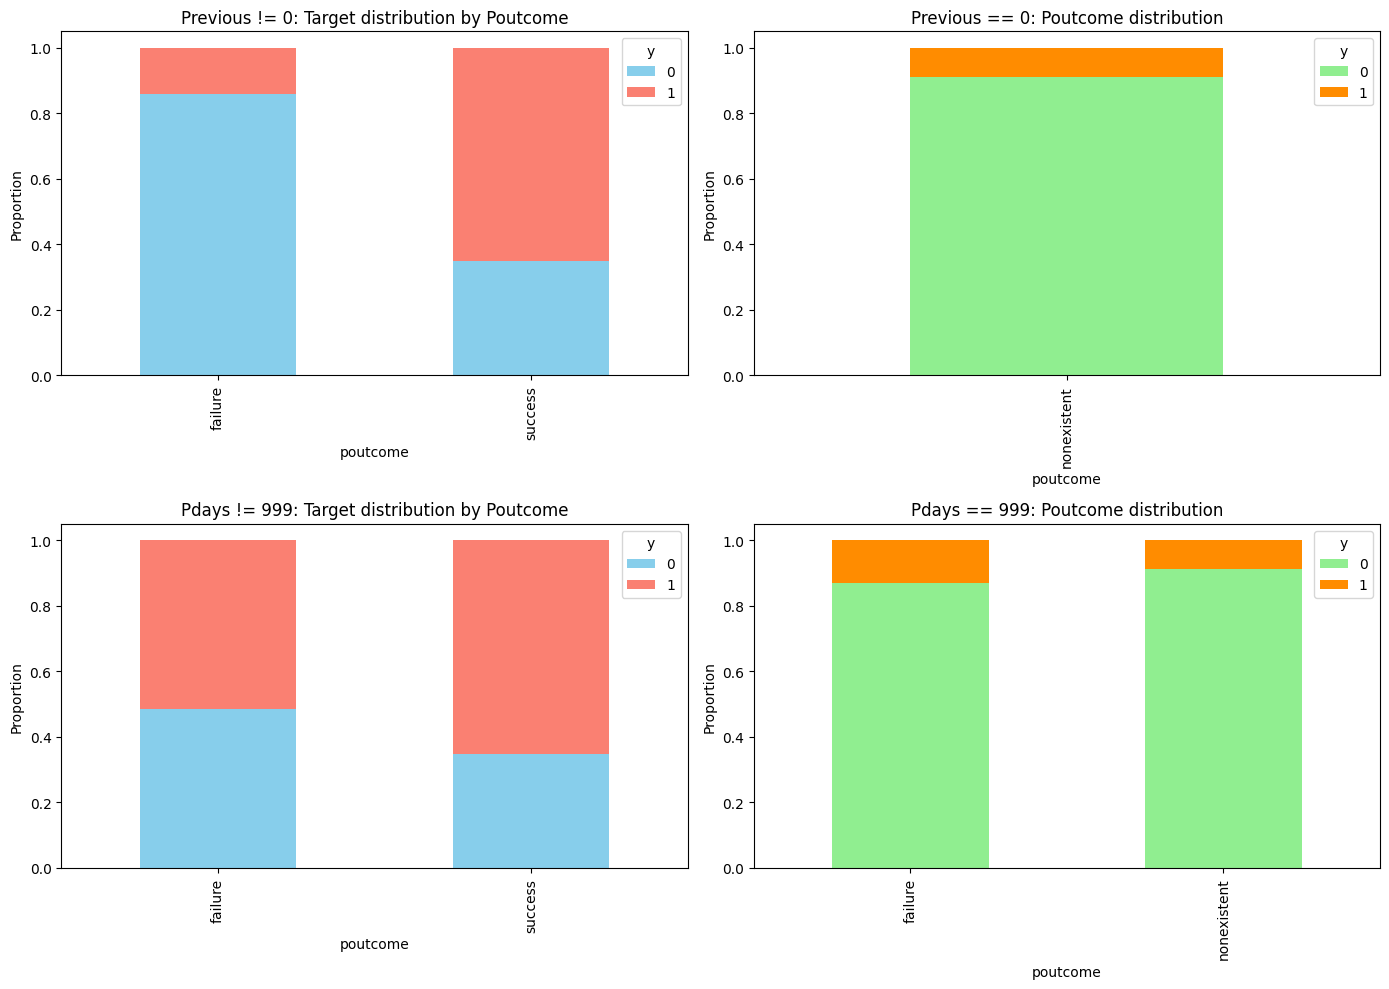

In [29]:
from src.visualizations import plot_previous_pdays_poutcome

plot_previous_pdays_poutcome(raw_df, target_col="y")

<span style="background-color: #4FC3F7; display:block; padding:10px">

**Conclusion – Feature `poutcome`**

- The categorical feature **`poutcome`** shows a **strong correlation with the numeric column `previous`** and a **slight correlation with `pdays`**.

- Values **`failure`** and **`success`** in `poutcome` are associated with **different probabilities of the target value `yes`**, indicating predictive power.

- Observed pattern:
  - **`previous = 0`** is always `poutcome = nonexistent`
  - **`previous != 0`** is always `poutcome = failure` or `success`

**Modeling considerations**

- Because `poutcome` and `previous` are tightly linked, including all three columns (`previous`, `pdays`, `poutcome`) as-is could introduce **multicollinearity and noise**.
- A reasonable approach:
  - Encode only **`poutcome = failure`** and **`poutcome = success`**
  - Treat `previous = 0` (nonexistent) as **implicit in `poutcome`**, reducing redundancy
- This transformation captures the predictive signal while **avoiding unnecessary correlation with `previous`**.

</span>

### Contact column

In [30]:
categorical_df["contact"].value_counts()

contact
cellular     26144
telephone    15044
Name: count, dtype: int64

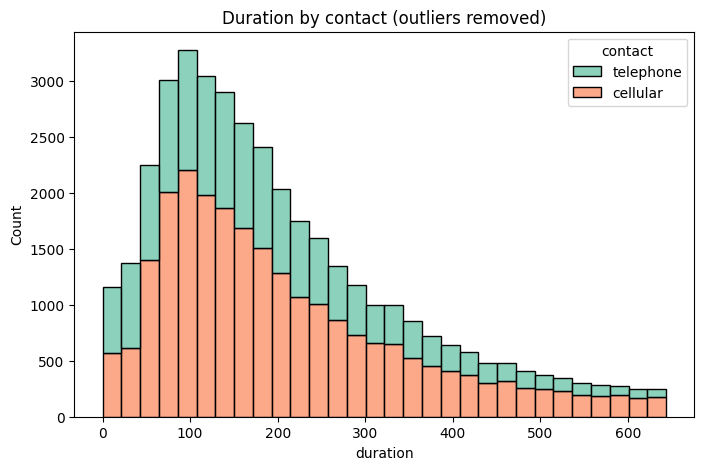

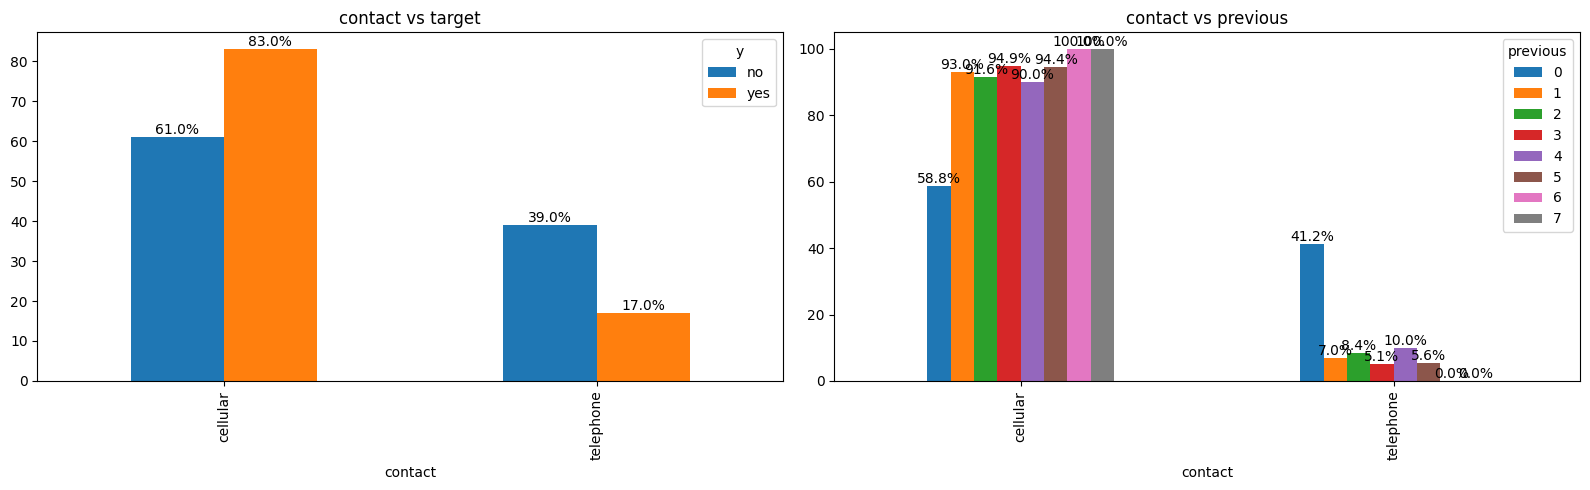

In [31]:
plot_histogram(
    remove_outliers_iqr(raw_df, "duration"),
    "duration",
    target_col="contact",
    show_pct=False,
    title="Duration by contact (outliers removed)",
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes = axes.flatten()
draw_countplot(
    raw_df,
    "contact",
    hue_col=target_col,
    normalize=True,
    title="contact vs target",
    ax=axes[0],
)
draw_countplot(
    raw_df,
    "contact",
    hue_col="previous",
    normalize=True,
    title="contact vs previous",
    ax=axes[1],
)

plt.tight_layout()
plt.show()


<span style="background-color: #4FC3F7; display:block; padding:10px">

**Conclusion – Feature `contact`**

- The **`contact`** method initially appears to influence the target: clients contacted via **`cellular`** show a **higher probability of subscription (`yes`)** compared to those contacted via **`telephone`**.

- On closer inspection, the **`contact`** value seems correlated with the **`previous`** feature:
  - More clients with **`contact = cellular`** have **`previous > 0`** (previous contacts), whereas **`telephone`** contacts have fewer.
  - This correlation could explain why `cellular` shows higher target probability — it may **reflect prior engagement** rather than the contact method itself.

- **Modeling considerations:**
  - It is unclear whether the contact method would be known **at the time of prediction**, and its apparent effect could be due to correlation with `previous`.
  - Therefore, it is reasonable to **exclude `contact` from the final model** to avoid potential **data leakage** and spurious correlations.

</span>

### Categorical Feature Relationships
#### Job vs. marital

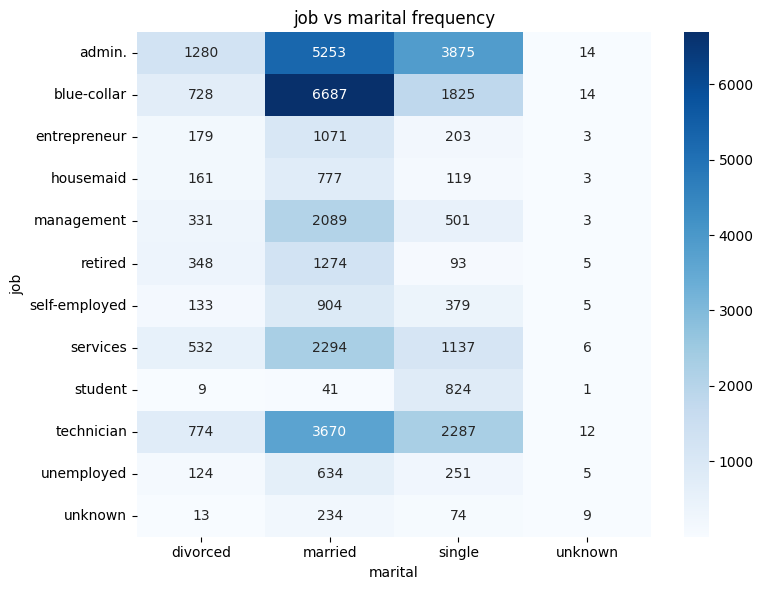

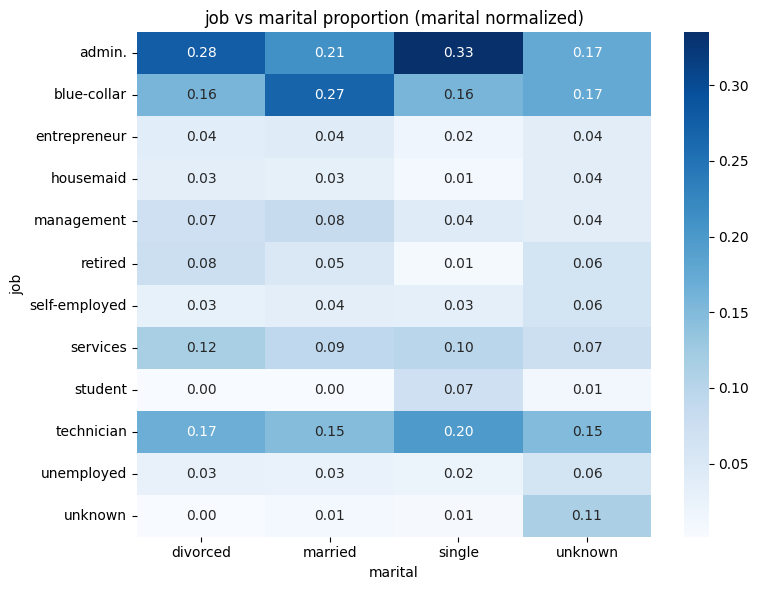

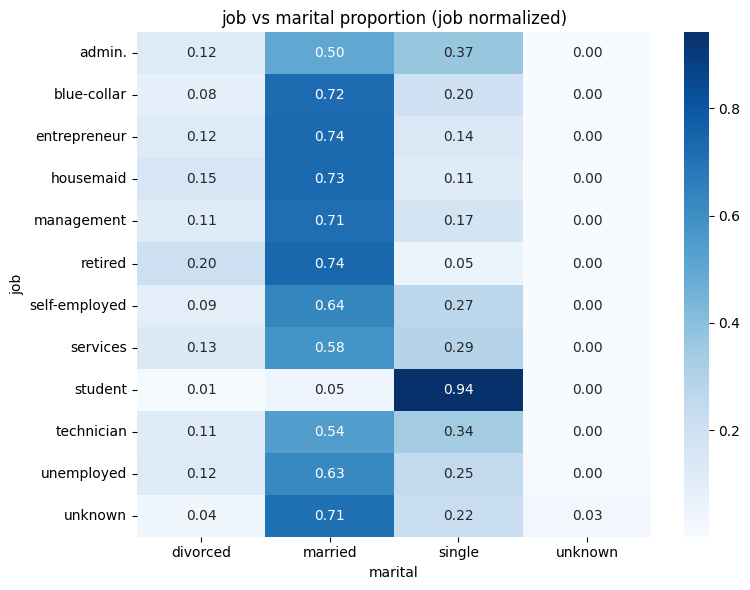

In [32]:
from src.visualizations import plot_categorical_heatmap

plot_categorical_heatmap(categorical_df, "job", "marital")
plot_categorical_heatmap(categorical_df, "job", "marital", normalize="columns", title="job vs marital proportion (marital normalized)")
plot_categorical_heatmap(categorical_df, "job", "marital", normalize="index", title="job vs marital proportion (job normalized)")

<span style="background-color: #4FC3F7; display:block; padding:10px">

**Conclusion – Relationship between `job` and `marital`**

- Certain **jobs** show clear associations with **marital status**:
  - **`admin.`**, **`technician`**, and **`services`** are more often **`divorced`** or **`single`**.
  - **`blue-collar`**, **`entrepreneur`**, and **`housemaid`** are more often **`married`**.
  - **`retired`** clients are more often **`divorced`**.
  - **`student`** clients are almost always **`single`**.

**Modeling considerations**

- These relationships indicate **dependency between `job` and `marital`**, meaning the features may capture **related aspects of a client's socio-economic profile**.
- Despite this dependency, both features may still provide **useful predictive information** for the target variable.
- When encoding these categorical variables, **one-hot encoding is appropriate**.

**Decision**

- Keep both **`job`** and **`marital`** features in the model.
- Encode them using **one-hot encoding**.
- Consider **dropping the `unknown` category** for both variables as it appears rarely and introduces ambiguity in the data.

</span>

#### Job vs. education

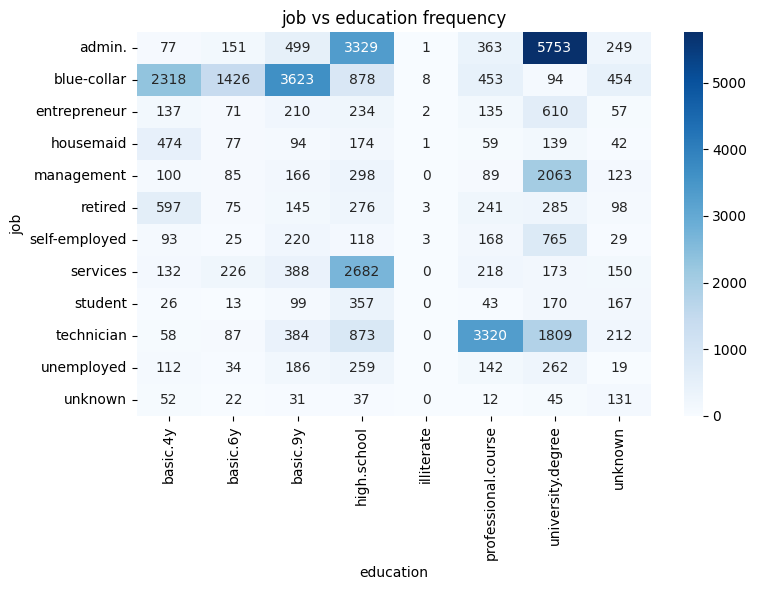

In [33]:
plot_categorical_heatmap(categorical_df, "job", "education")

<span style="background-color: #4FC3F7; display:block; padding:10px">

**Conclusion – Relationship between `education` and `job`**

- Certain **education levels** are associated with specific **jobs**:
  - **`basic`** education levels are more likely to correspond to **`blue-collar`** jobs.
  - **`high-school`** education is more likely to correspond to **`services`** jobs.
  - **`technical`**, **`admin.`**, **`self-employed`**, **`management`**, and **`entrepreneur`** jobs are more inclined to have a **`university-degree`**.
  - **`management`** is mostly associated with **`university-degree`** education.
  - **`professional-course`** education is mostly associated with **`technical`** jobs.

**Modeling considerations**

- There is a **strong dependency between `education` and `job`**, as certain occupations tend to require specific education levels.
- This relationship may introduce **redundancy between the two features**, as they partially capture similar socio-economic information.
- However, each feature may still contain **complementary predictive information** for the target variable.

**Decision**

- Keep both **`education`** and **`job`** features in the model.
- Encode them using **one-hot encoding**.
- Monitor potential **redundancy or multicollinearity effects** during modeling and feature importance evaluation. Consider dropping `unknown` values

</span>

#### Education vs. default & loan

In [57]:
categorical_df["default"].value_counts(), categorical_df["loan"].value_counts()

(default
 no         32588
 unknown     8597
 yes            3
 Name: count, dtype: int64,
 loan
 no         33950
 yes         6248
 unknown      990
 Name: count, dtype: int64)

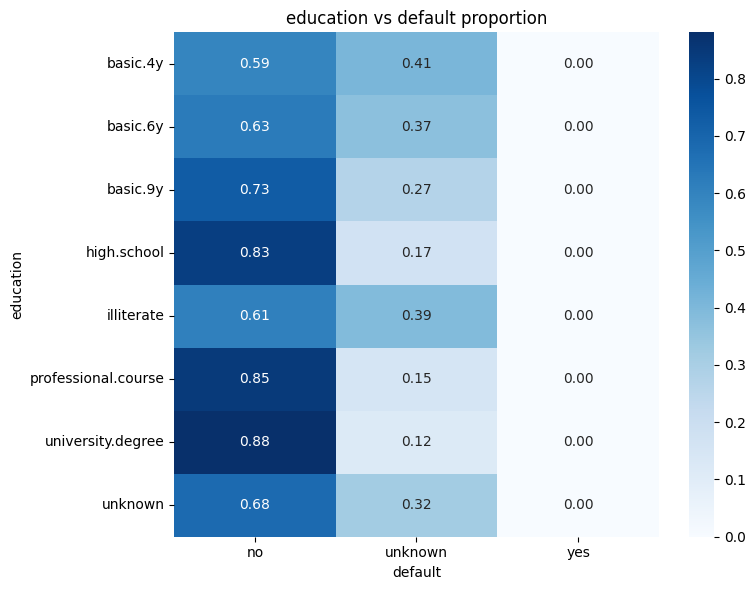

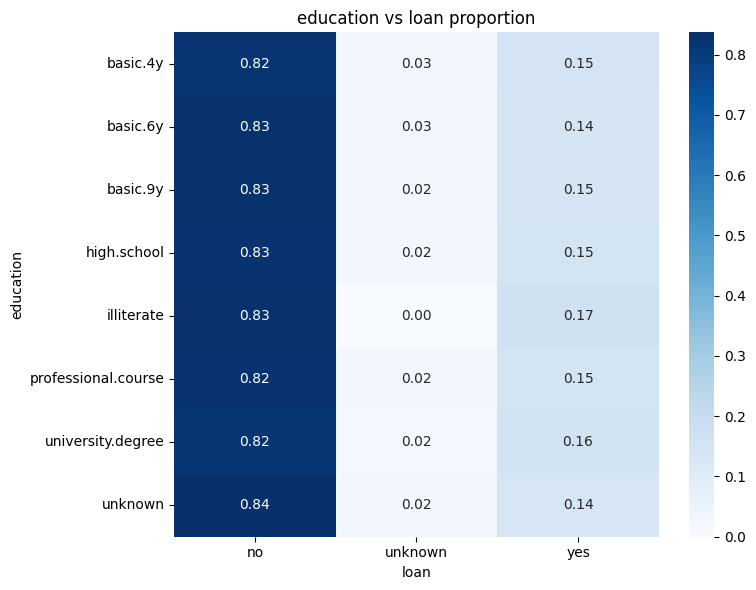

In [63]:
plot_categorical_heatmap(categorical_df, "education", "default", normalize="index")
plot_categorical_heatmap(categorical_df, "education", "loan", normalize="index")

<span style="background-color: #4FC3F7; display:block; padding:10px">

**Conclusion – Relationship between `education`, `default`, and `loan`**

- Clients with **lower education levels** have a **higher probability of `unknown`** `default` status.
- Clients with **higher education levels** have a **higher probability of `no`** `default` status.
- At the same time there is **no noticeable correlation between `loan` and `education`** status

**Modeling considerations**

- There appears to be a **relationship between `education` and `default`**, suggesting that both features may contain **useful predictive information**.
- The **`unknown` category in `default` is relatively large**, which may indicate **missing or unreported credit history**, potentially carrying predictive value.

**Decision**

- Keep both **`education`** and **`default`** features in the model.
- Encode them using **one-hot encoding**.
- Consider **combining `default = yes` and `default = unknown` into a single category representing potential credit risk**, depending on model performance.

</span>

#### Month vs. day_of_week

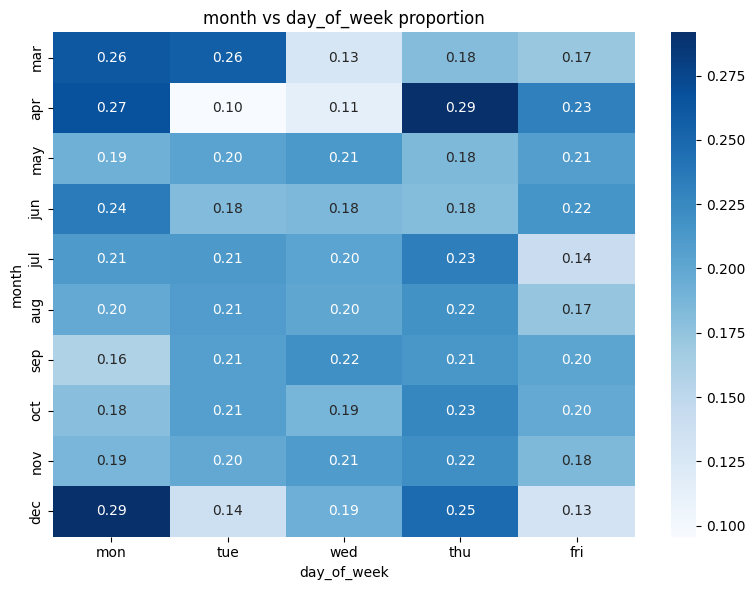

In [35]:
# Define the correct chronological order
months_order = ["jan", "feb", "mar", "apr", "may", "jun",
                "jul", "aug", "sep", "oct", "nov", "dec"]
days_order = ["mon", "tue", "wed", "thu", "fri", "sat", "sun"]

plot_categorical_heatmap(
    categorical_df,
    col1="month",
    col2="day_of_week",
    normalize="index",
    row_order=months_order,
    col_order=days_order
)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**Conclusion – Features `month` and `day_of_week`**

- The **`month`** and **`day_of_week`** features are **not evenly distributed** in the dataset.
  - For example:
    - **`mar`** has more **`mon`** and **`tue`** entries.
    - **`apr`** and **`dec`** have more **`mon`** and **`thu`** entries.
- There is **no data for `jan` and `feb`** in the dataset.
- Only **weekdays** are present - no **`sat`** or **`sun`** values in `day_of_week`.

**Modeling considerations**

- The **uneven distribution** reflects the **data collection process** rather than a true absence of these periods in reality.
- Both **`month`** and **`day_of_week`** are **categorical time-related features** that may capture seasonal or temporal patterns in campaign responses.
- **One-hot encoding** is recommended to avoid imposing artificial ordinal relationships.
- Alternatively, **cyclical encoding** using `sin` and `cos` can be considered to capture the natural **cyclical patterns** of days of the week or months (e.g., `sin(2π*day/7)` for weekdays).


**Decision**

- Keep both **`month`** and **`day_of_week`** features in the model.
- Encode them using **one-hot encoding** to avoid imposing artificial ordinal relationships.
- Be aware that **`jan`, `feb`, `sat`, and `sun` are absent from the dataset**, so the model will not learn patterns for these categories.

</span>

### Feature Interaction vs Target
#### job & marital vs target

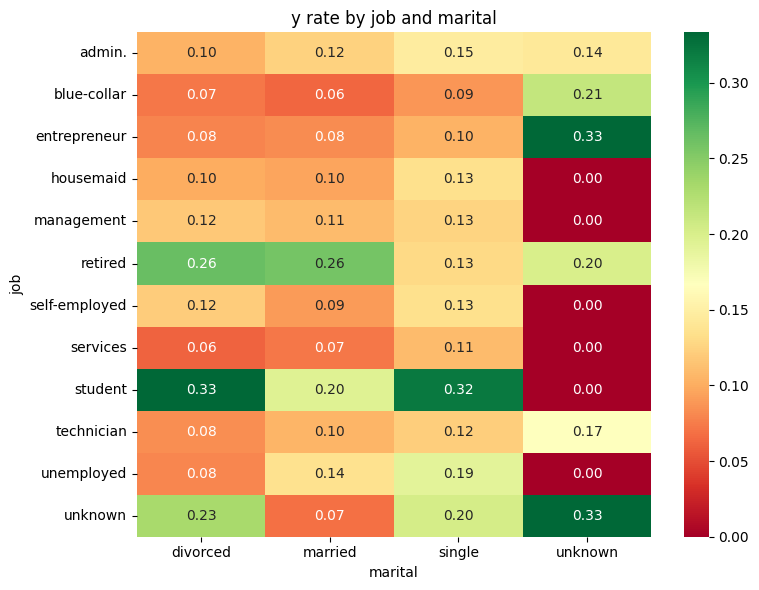

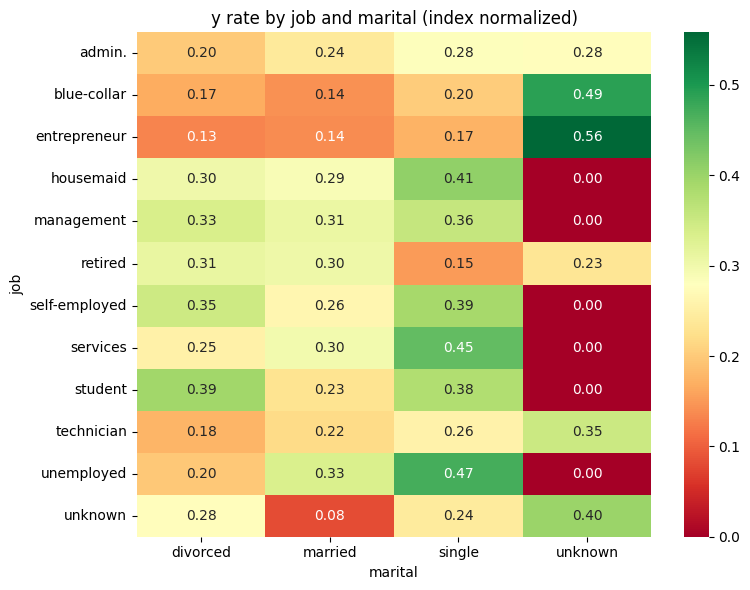

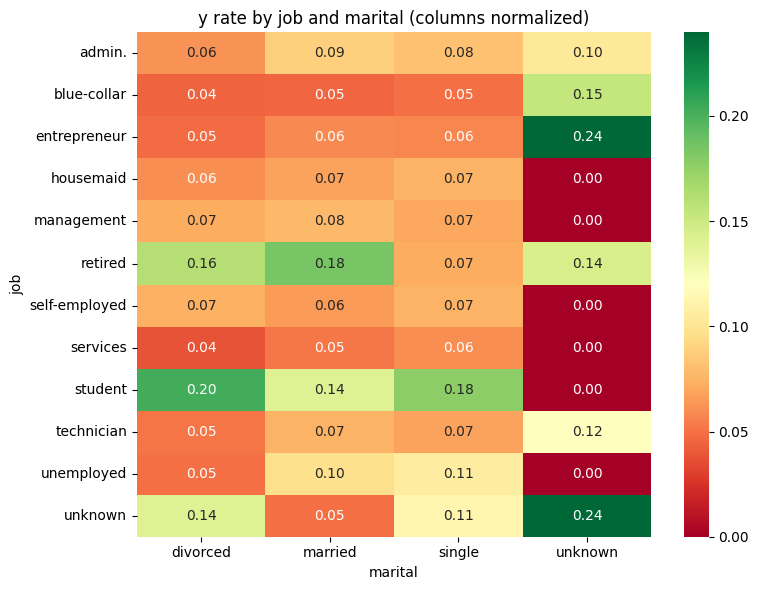

In [36]:
from src.visualizations import plot_target_rate_heatmap

plot_target_rate_heatmap(
    categorical_df,
    "job",
    "marital",
    target_col,
    normalize=None
)

plot_target_rate_heatmap(
    categorical_df,
    "job",
    "marital",
    target_col,
    normalize="index"
)

plot_target_rate_heatmap(
    categorical_df,
    "job",
    "marital",
    target_col,
    normalize="columns"
)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**Conclusion – Features `marital` and `job`**

- **Marital status**:
  - **`single`** clients have a **higher probability of `yes`** target.
  - **`married`** clients have a **lower probability of `yes`** target.
  - **`divorced`** clients are in the **middle**.

- **Job**:
  - **`student`** and **`retired`** clients have a **higher probability of `yes`** target compared to other jobs.

**Modeling considerations**

- Both **`marital`** and **`job`** are **categorical variables** with multiple distinct categories.
- The observed differences between categories suggest that **both features may contain useful predictive information**.
- The **`unknown`** category in both variables represents **missing or ambiguous information**, which may introduce noise into the model.

**Decision**

- Keep both **`marital`** and **`job`** features in the model.
- Encode them using **one-hot encoding** to avoid introducing artificial ordinal relationships.
- Consider **dropping the `unknown` category** as it appears not too often to avoid ambiguity and multicollinearity during modeling.

</span>

#### Education & default vs. target

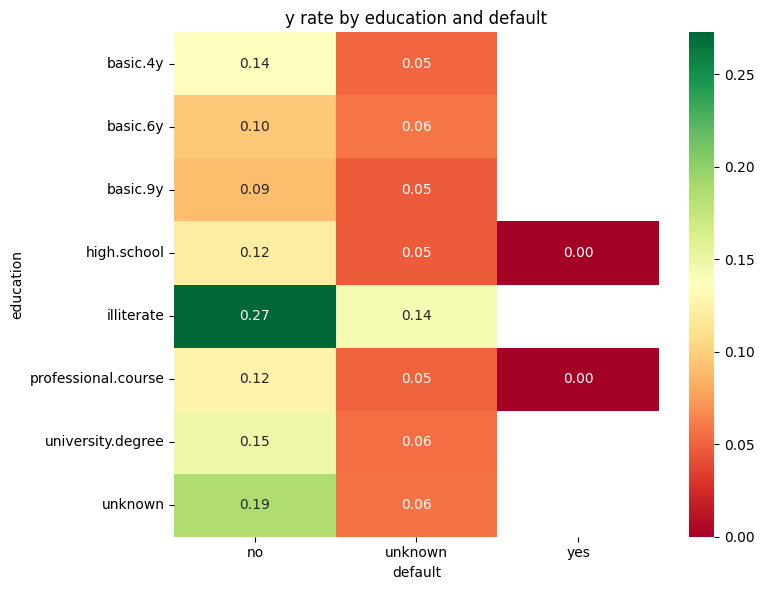

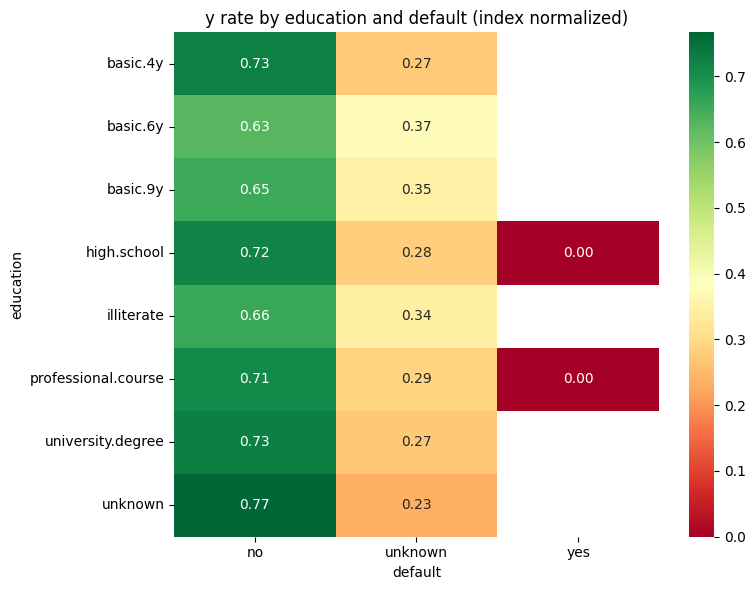

In [37]:
plot_target_rate_heatmap(
    categorical_df,
    "education",
    "default",
    target_col,
    normalize=None
)

plot_target_rate_heatmap(
    categorical_df,
    "education",
    "default",
    target_col,
    normalize="index"
)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**Conclusion – Feature `default`**

- Clients with **`default = no`** have a **higher probability of the target value `yes`** compared to other categories.

**Modeling considerations**

- The **`default`** feature appears **predictive** and may provide useful information for the target variable.
- It is a **categorical variable**, so **one-hot encoding** is recommended for modeling.
- The **`unknown`** category represents missing or unreported credit history. It may be **combined with `yes`** to represent potential credit risk, depending on model performance and prevalence of `unknown`.

**Decision**

- Keep the **`default`** feature in the model.
- Encode using **one-hot encoding**.
- Consider **combining `default = unknown` and `default = yes`** into a single category to capture potential risk, if appropriate.

</span>

#### Month & day_of_week vs. target

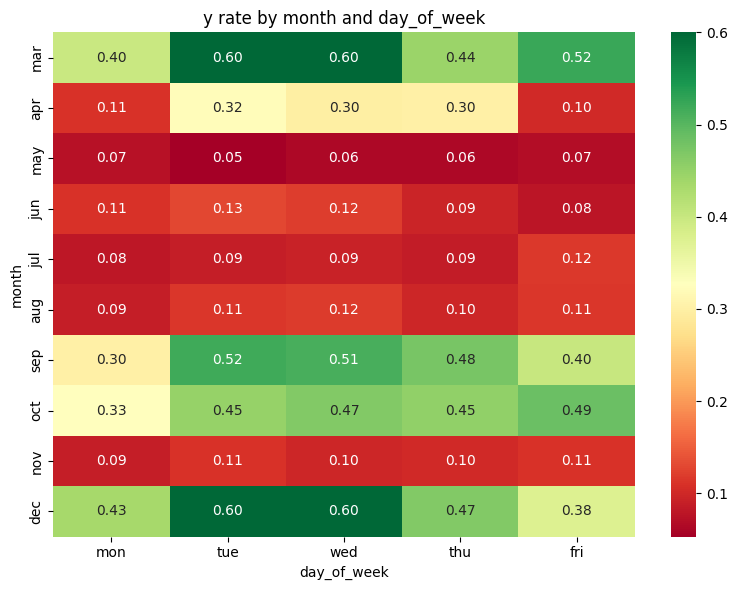

In [ ]:
plot_target_rate_heatmap(
    categorical_df,
    "month",
    "day_of_week",
    target_col,
    row_order=months_order,
    col_order=days_order,
    # normalize="all",
)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**Conclusion – Features `day_of_week` and `month`**

- Certain **days of the week** show higher probability of the target value `yes`:
  - **`tue`** and **`wed`** provide the best likelihood of `yes`.

- Certain **months** are more favorable for the target:
  - **Higher probability of `yes`**: `mar`, `sep`, `oct`, `dec`
  - **Lower probability of `yes`**: `may`, `jun`, `jul`, `aug`

**Implications for modeling:**

- Both **`day_of_week`** and **`month`** are predictive features.
- One-hot encoding is recommended to capture these patterns without implying ordinal relationships.
- Rare or missing categories (`jan`, `feb`, `sat`, `sun`) should be handled carefully to avoid sparse features.

</span>

#### housing & loan vs. target

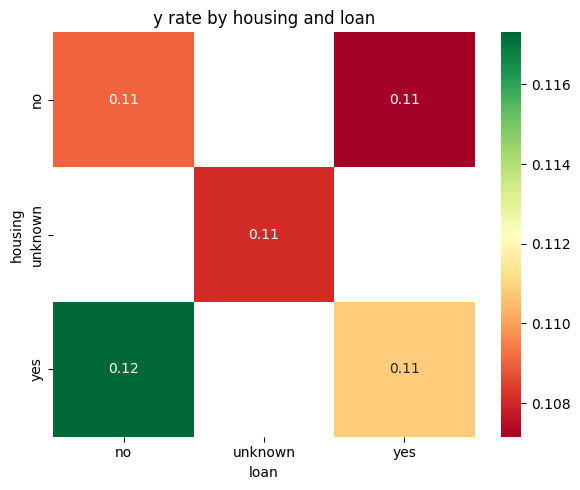

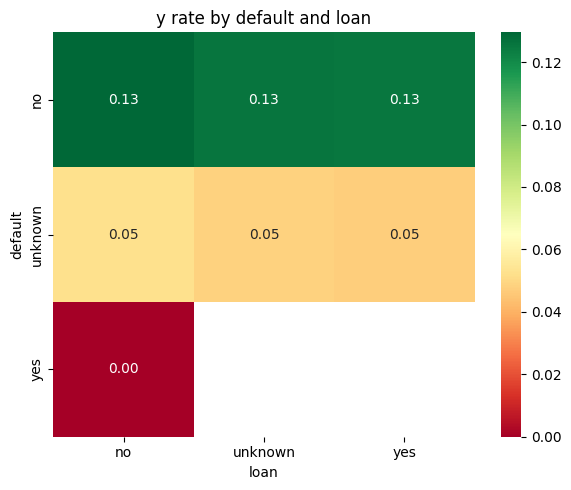

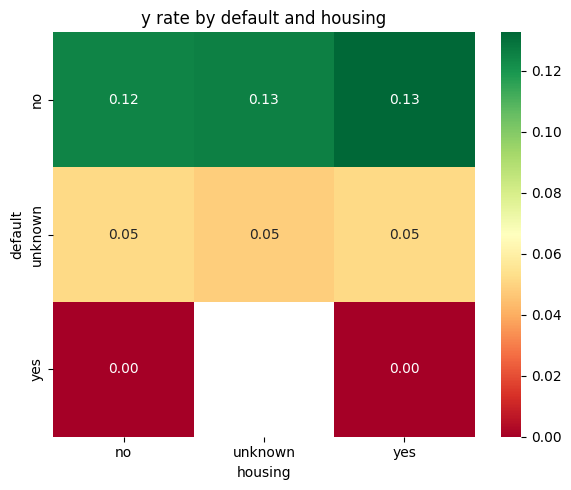

In [64]:
plot_target_rate_heatmap(
    categorical_df,
    "housing",
    "loan",
    target_col,
    figsize=(6, 5),
)

plot_target_rate_heatmap(
    categorical_df,
    "default",
    "loan",
    target_col,
    figsize=(6, 5),
)
plot_target_rate_heatmap(
    categorical_df,
    "default",
    "housing",
    target_col,
    figsize=(6, 5),
)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**Conclusion – Features `loan` and `housing`**

- The **`loan`** and **`housing`** features do **not show a noticeable relationship with the target variable**.
- There is **no apparent predictive signal** in these columns for this dataset.

**Modeling considerations**

- Both features are **categorical**, but preliminary analysis suggests **limited usefulness for prediction**.
- Including them in the model is unlikely to improve performance.
- Retaining them may slightly increase model complexity without meaningful gain.

**Decision**

- Consider **dropping `loan` and `housing`** from the final predictive model.
- If kept, encode them using **one-hot encoding**, but monitor feature importance to verify their contribution.

</span>

## Final thoughts & conclusions
### EDA Summary and Hypotheses
<span style="display:block; padding:10px">

**EDA Summary and Hypotheses – Target Feature `y`**

Exploratory data analysis reveals several patterns between client characteristics, campaign attributes, and the target variable `y`.

**Client demographics**

- **Age** influences response probability: clients **younger than ~30** and **older than 60** show **higher likelihood of `yes`**.
- **Marital status** also matters: **`single`** clients respond more often than **`married`** clients.
- **Education level** shows a mild relationship, with **higher education levels slightly increasing the probability of `yes`**.

**Socio-economic profile**

- **Job type** appears predictive, particularly for **`student`** and **`retired`** clients.
- Strong relationships exist between **`education`**, **`job`**, and **`marital`**, suggesting they capture related socio-economic characteristics.

**Financial status**

- Clients with **`default = no`** show **higher probability of `yes`**.
- **`loan`** and **`housing`** features show **little predictive signal**.

**Marketing interaction history**

- **Previous campaign interactions** are important:  
  clients contacted before (`previous > 0` or `pdays != 999`) show **higher response probability**.
- A **higher number of campaign contacts (`campaign`)** correlates with **lower success probability**.

**Temporal effects**

- Response rates vary across **months and weekdays**:  
  higher in **`mar`, `sep`, `oct`, `dec`** and slightly higher on **`tue` and `wed`**.

**Important modeling note**

- The **`duration`** feature strongly correlates with the target but represents **call duration after contact**, introducing **data leakage**.  
  Therefore, it will **not be used in the predictive model**.

**Overall hypothesis**

Campaign success (`y = yes`) appears to depend mainly on:

- **Client demographics and socio-economic profile**
- **Previous marketing interactions**
- **Temporal campaign patterns**

These factors are expected to provide the strongest predictive signal for the model.

</span>

### Columns data

**Feature preparation plan based on EDA**

- `age` (numeric):
  - Use as a **model feature** without transformation.

- `job` (categorical):
  - Use as a **model feature**.  
  - Apply **one-hot encoding**.  
  - Drop the `unknown` category.

- `marital` (categorical):
  - Use as a **model feature**.  
  - Apply **one-hot encoding**.  
  - Drop the `unknown` category.

- `education` (categorical):
  - Use as a **model feature**.  
  - Apply **one-hot encoding**.  
  - Drop `unknown` and `illiterate` categories due to ambiguity and very low frequency.

- `default` (categorical):
  - Use as a **model feature**.  
  - Apply **one-hot encoding**.  
  - Combine `unknown` and `yes` into a single category representing **potential credit risk**.

- `housing`, `loan` (categorical):
  - These features **do not demonstrate noticeable predictive power** during EDA.  
  - Initial decision: **exclude them from the model**.  
  - Final decision will be confirmed after building **baseline models** and analyzing **feature importance and statistical significance**.

- `contact` (categorical):
  - Shows **strong correlation with `previous`**.  
  - Initial decision: **exclude from the model** to avoid redundancy.

- `month` (categorical):
  - Use as a **model feature**.  
  - Apply **one-hot encoding**.  
  - Additionally, experiment with **cyclical encoding** and compare model performance.

- `day_of_week` (categorical):
  - Use as a **model feature**.  
  - Apply **one-hot encoding**.  
  - Optionally experiment with **cyclical encoding** and compare model performance.

- `duration` (numeric):
  - **Exclude from the model** due to **data leakage**, since it represents call duration known only after the interaction.

- `campaign` (numeric):
  - Transform to represent the **number of previous contacts**:  
  - `campaign_prev = min(campaign - 1, 5)`  
  - Use this transformed feature as a **model feature** to reduce the influence of extreme values.

- `pdays` (numeric):
  - Transform into **categorical groups** before modeling.  
  - Possible options:  
    - Binary indicator: `pdays_contacted = 1` if `pdays != 999`, otherwise `0`  
    - Multi-class grouping such as:  
      - `not_contacted_before`  
      - `contacted_recently`  
      - `contacted_long_ago`  
  - Compare model performance across alternatives.

- `previous` (numeric):
  - Use as a **model feature** without transformation.

- `poutcome` (categorical):
  - Use as a **model feature**.  
  - Apply **one-hot encoding**.  
  - Drop the `nonexistent` category as it is strongly correlated with `previous = 0`.

- `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed` (numeric):
  - These **macro-economic indicators** may be correlated with each other.  
  - Perform additional analysis to evaluate **feature importance and statistical significance**.  
  - Potential approaches:  
    - Select the **most informative variables**.  
    - Apply **feature engineering** to combine them into fewer representative features.
    - Apply **binning** monotonic variables into categorical flags (e.g., `low / high`)

### Model Evaluation Metric

The dataset shows **class imbalance**, where the majority of observations correspond to **`y = no`**, while **`y = yes`** occurs much less frequently. Because of this, **accuracy alone can be misleading**, as a model predicting only `no` could still achieve high accuracy.

For this reason, **F1-score** is selected as the primary evaluation metric.

**Reasons for choosing F1-score**

- **Handles class imbalance** by balancing **precision** and **recall**.
- **Penalizes both false positives and false negatives**, which is important for marketing campaigns.
- **Focuses on performance for the minority class (`yes`)**, which is the main business interest.

**Additional metrics monitored**

- **Precision** – limits unnecessary client contacts  
- **Recall** – ensures potential subscribers are not missed  
- **ROC-AUC** – evaluates overall model discrimination ability  
- **Confusion Matrix** – provides detailed error analysis

### Additional Considerations

- Due to **class imbalance in the target variable**, experiment with **re-sampling techniques** such as **SMOTE**, **ADASYN**, or **SMOTETomek** to improve the model’s ability to learn patterns from the minority class.